c:\Users\aniru\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: 1590700.1934538507
            Iterations: 7
            Function evaluations: 1448
            Gradient evaluations: 3
Optimization terminated successfully    (Exit mode 0)
            Current function value: 384.9443999999822
            Iterations: 2
            Function evaluations: 4
            Gradient evaluations: 2


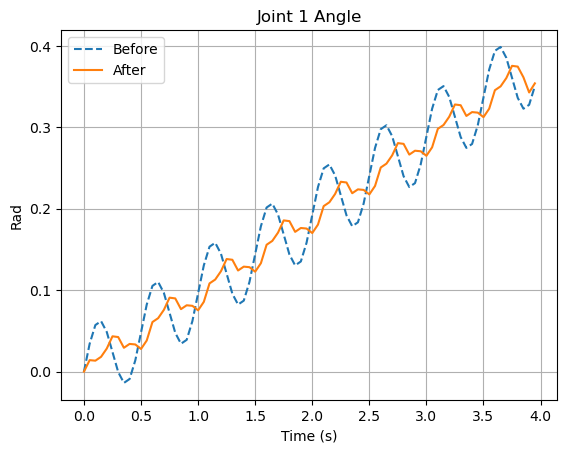

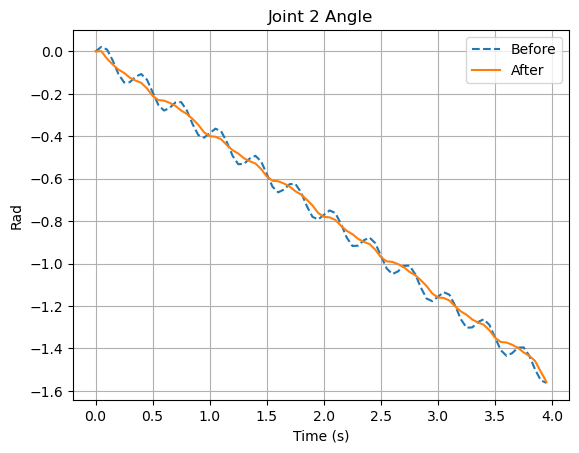

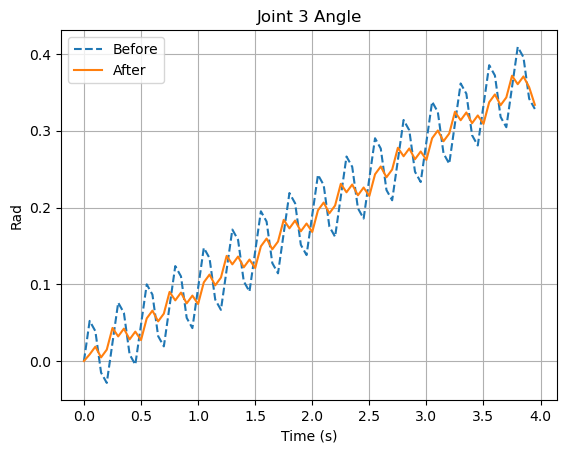

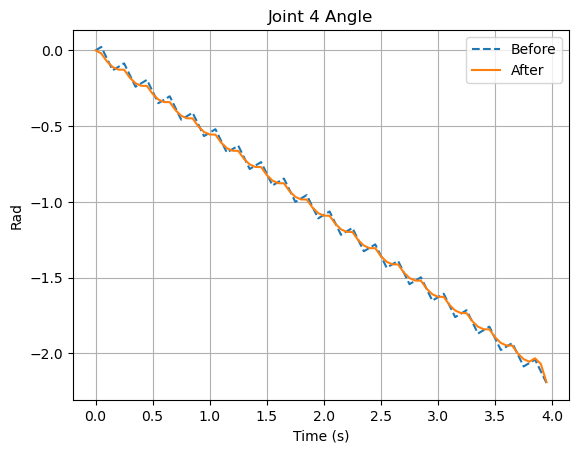

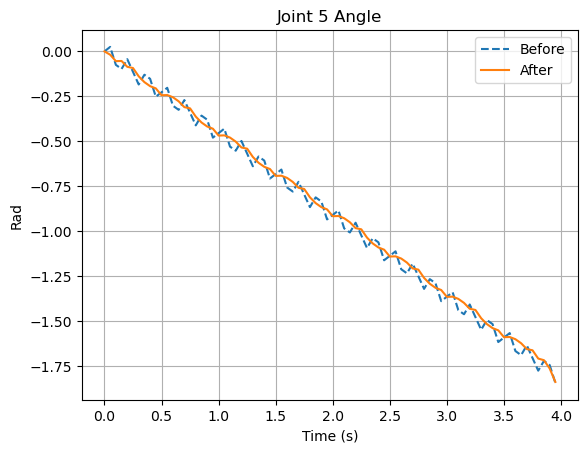

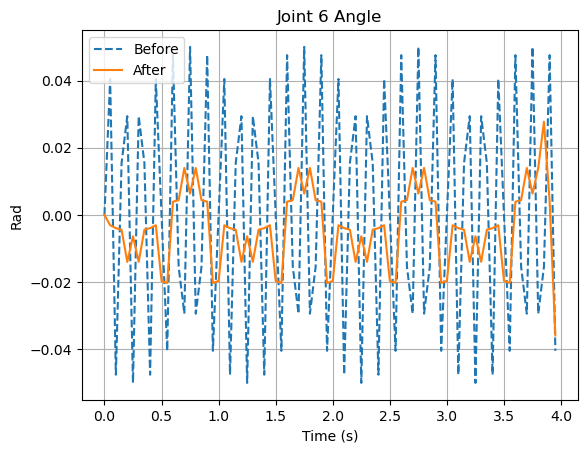

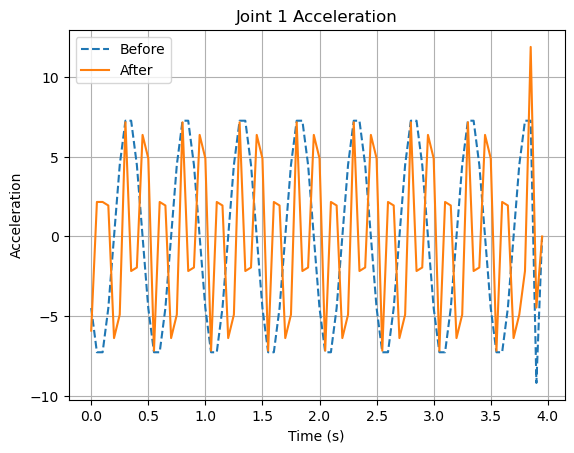

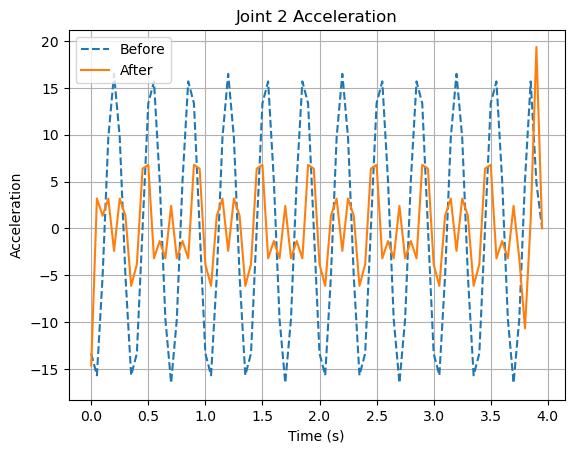

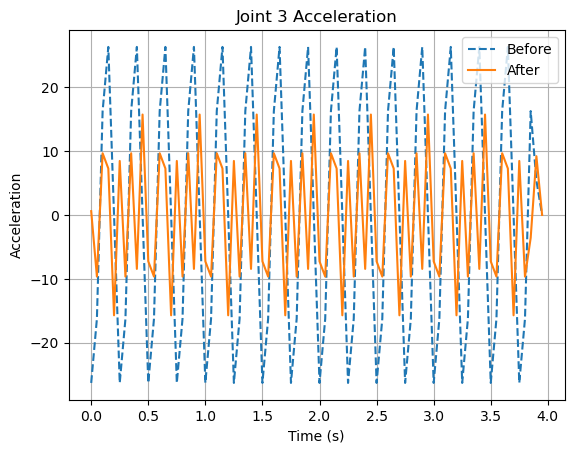

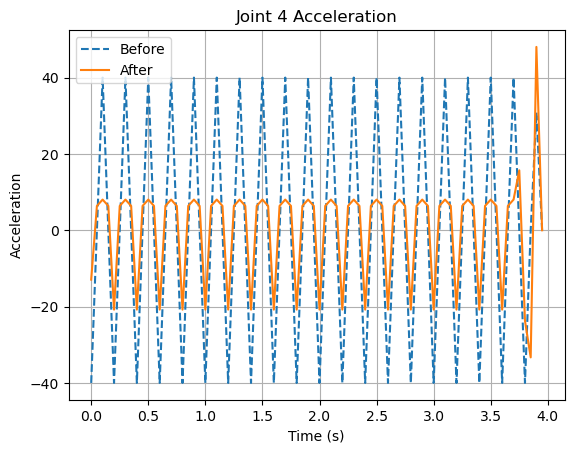

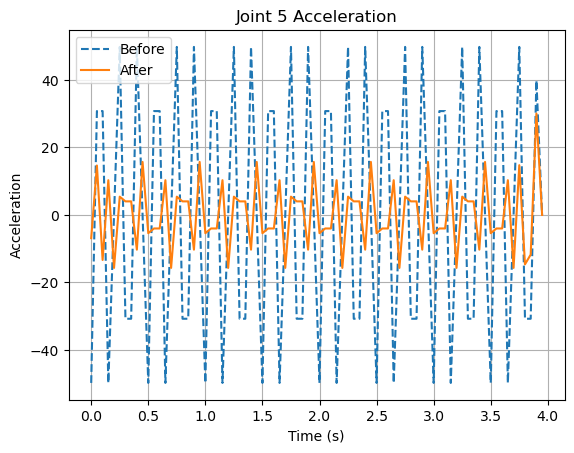

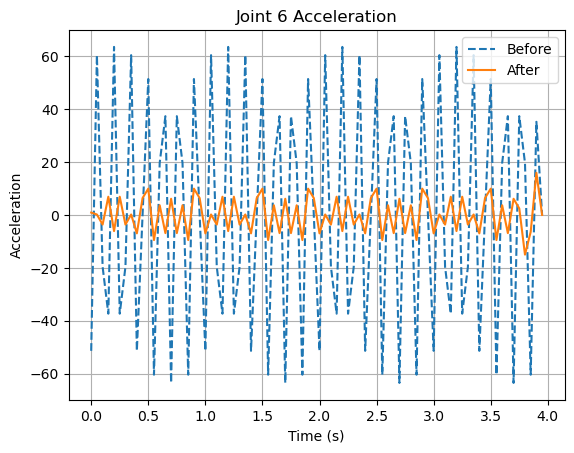

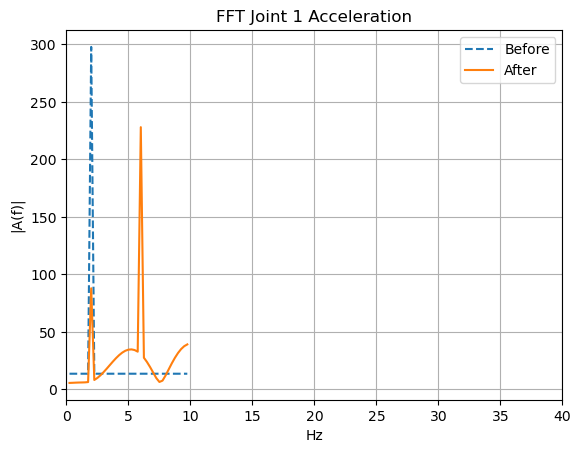

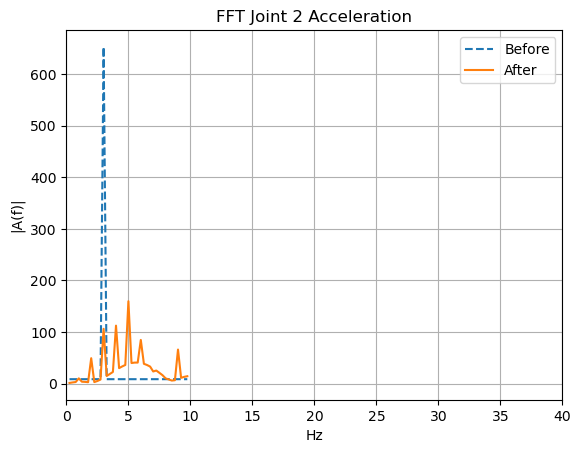

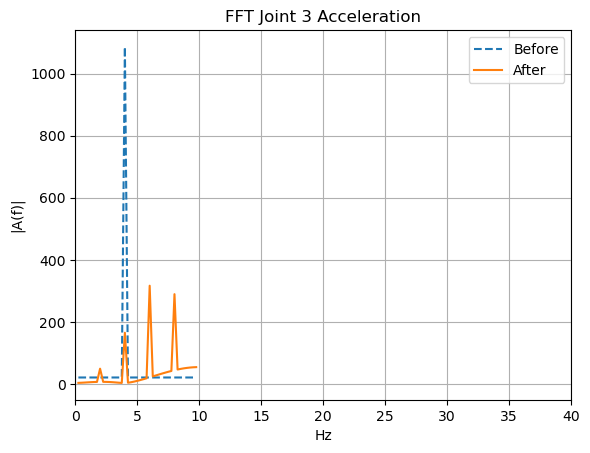

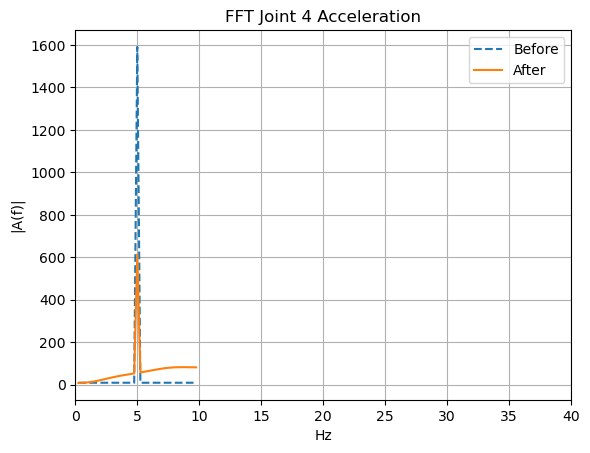

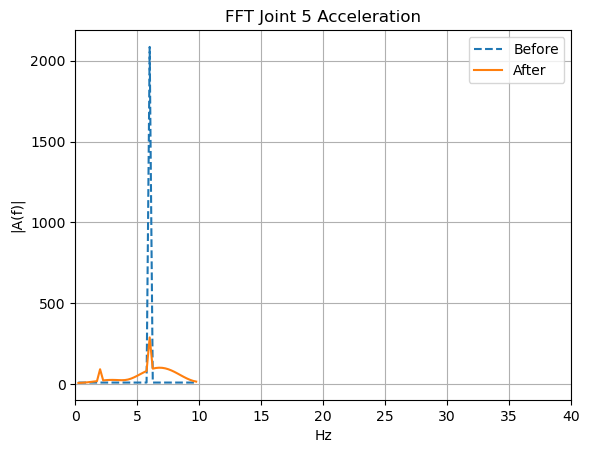

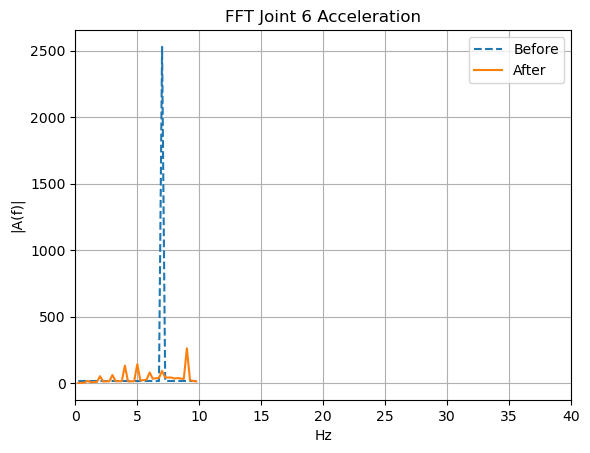

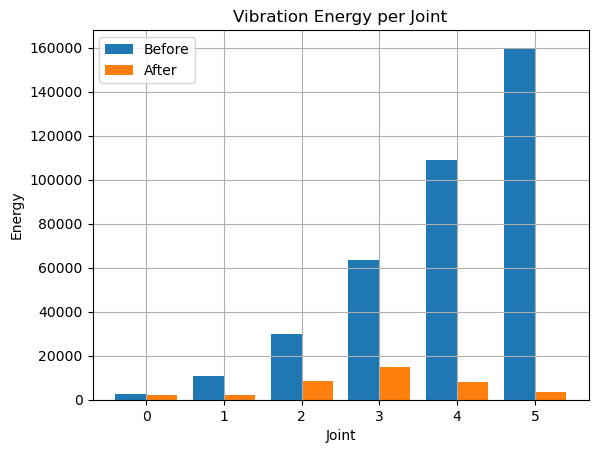

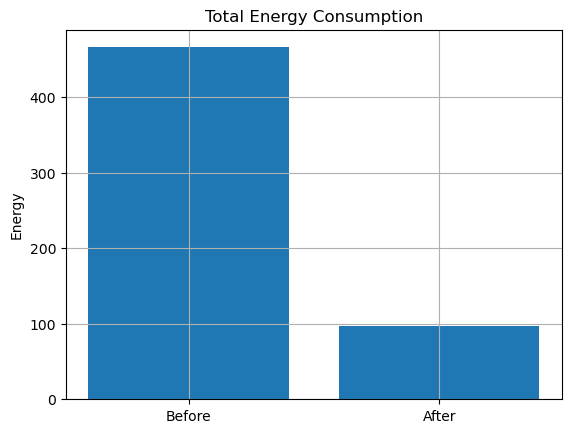

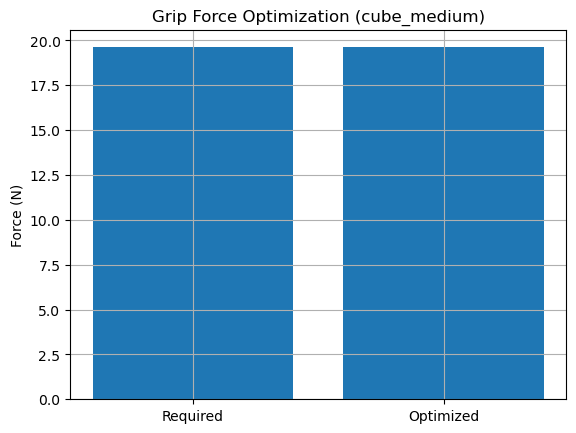

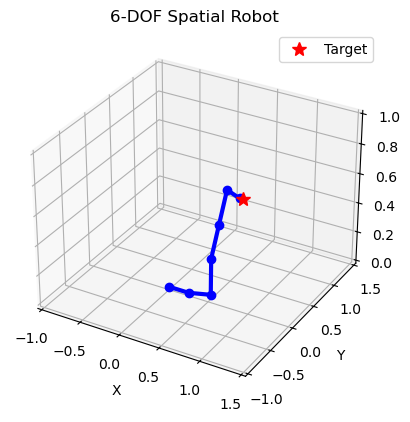

Grip force optimization success: True
Optimized grip force: 19.62 N
Required grip force : 19.62 N


: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.fft import fft, fftfreq
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.max_open_warning'] = 50

# ================== PARAMETERS ==================
DOF = 6
T = 80
dt = 0.05
time = np.arange(T) * dt

alpha = 0.5
beta = 15.0
delta = 0.0
q_min, q_max = -np.pi, np.pi

# ================== OBJECTS ==================
objects = {
    'cube_small': {'mass': 0.5, 'mu': 0.5},
    'cube_medium': {'mass': 1.2, 'mu': 0.6},
    'cylinder': {'mass': 0.8, 'mu': 0.55},
    'sphere': {'mass': 1.0, 'mu': 0.65}
}

obj_name = 'cube_medium'
mass = objects[obj_name]['mass']
mu = objects[obj_name]['mu']
g = 9.81

# ================== ROTATION MATRICES ==================
def rot_x(theta): return np.array([[1,0,0],[0,np.cos(theta),-np.sin(theta)],[0,np.sin(theta),np.cos(theta)]])
def rot_y(theta): return np.array([[np.cos(theta),0,np.sin(theta)],[0,1,0],[-np.sin(theta),0,np.cos(theta)]])
def rot_z(theta): return np.array([[np.cos(theta),-np.sin(theta),0],[np.sin(theta),np.cos(theta),0],[0,0,1]])

axes = ['z','y','y','x','y','x']
def rot(axis, theta):
    if axis=='x': return rot_x(theta)
    if axis=='y': return rot_y(theta)
    return rot_z(theta)

# ================== FORWARD KINEMATICS ==================
def forward_kinematics(q):
    l = np.ones(DOF) * 0.25
    T_mat = np.eye(4)
    for i in range(DOF):
        R = rot(axes[i], q[i])
        T_joint = np.eye(4)
        T_joint[:3,:3] = R
        T_joint[:3,3] = [l[i],0,0]
        T_mat = T_mat @ T_joint
    return T_mat[:3,3]

# ================== JACOBIAN ==================
def jacobian(q, eps=1e-6):
    J = np.zeros((3, DOF))
    f0 = forward_kinematics(q)
    for i in range(DOF):
        dq = q.copy()
        dq[i] += eps
        J[:,i] = (forward_kinematics(dq) - f0)/eps
    return J

# ================== INVERSE KINEMATICS ==================
def solve_ik(q_init, target, max_iter=500, tol=1e-4, damping=1e-3):
    q = q_init.copy()
    for _ in range(max_iter):
        ee = forward_kinematics(q)
        error = target - ee
        if np.linalg.norm(error) < tol: break
        J = jacobian(q)
        dq = np.linalg.solve(J.T @ J + damping*np.eye(DOF), J.T @ error)
        q += dq
        q = np.clip(q, q_min, q_max)
    return q

# ================== START & GOAL ==================
q_start = np.zeros(DOF)
target_position = np.array([0.7,0.4,0.6])
q_goal = solve_ik(q_start, target_position)

# ================== DERIVATIVES ==================
def derivatives(q):
    dq = np.diff(q, axis=0)/dt
    dq = np.vstack([dq,np.zeros((1,DOF))])
    ddq = np.diff(dq, axis=0)/dt
    ddq = np.vstack([ddq,np.zeros((1,DOF))])
    return dq, ddq

# ================== OBJECTIVE WITH FFT ==================
def objective(x):
    q = x.reshape(T,DOF)
    dq, ddq = derivatives(q)

    vel_cost = alpha*np.sum(dq**2)
    acc_cost = beta*np.sum(ddq**2)

    # FFT vibration penalty
    freqs = fftfreq(T, dt)
    fft_cost = 0.0
    for j in range(DOF):
        A = np.abs(fft(ddq[:,j]))
        fft_cost += np.sum(A[freqs > 1.0]**2)
    fft_cost *= 0.8

    return vel_cost + acc_cost + fft_cost

# ================== CONSTRAINTS ==================
def start_constraint(x): return x.reshape(T,DOF)[0]-q_start
def end_constraint(x): return x.reshape(T,DOF)[-1]-q_goal

constraints = [{'type':'eq','fun':start_constraint},{'type':'eq','fun':end_constraint}]

# ================== BASELINE TRAJECTORY ==================
q_initial = q_start + np.outer(time/time[-1], (q_goal-q_start))
for i in range(DOF):
    freq = 2+i
    amplitude = 0.05
    q_initial[:,i] += amplitude*np.sin(2*np.pi*freq*time)
x0 = q_initial.flatten()

# ================== OPTIMIZATION ==================
result = minimize(objective, x0, method='SLSQP',
                  bounds=[(q_min,q_max)]*(T*DOF),
                  constraints=constraints,
                  options={'maxiter':1000,'ftol':1e-5,'disp':True})
q_opt = result.x.reshape(T,DOF)

# ================== GRIP FORCE ==================
def grip_objective(Fg): return Fg**2
def grip_constraint(Fg): return Fg - mass*g/mu
grip_result = minimize(grip_objective, x0=np.array([mass*g/mu*1.2]),
                       bounds=[(0,200)],
                       constraints={'type':'ineq','fun':grip_constraint},
                       options={'disp': True})
Fg_opt = grip_result.x[0]
F_required = mass*g/mu

# ================== DERIVATIVES & FFT ==================
dq_init, acc_before = derivatives(q_initial)
dq_opt, acc_after  = derivatives(q_opt)
freqs = fftfreq(acc_before.shape[0], dt)
pos_freq = freqs>0
fft_before = np.abs(fft(acc_before, axis=0))
fft_after = np.abs(fft(acc_after, axis=0))

# ================== PLOTS (Joint, Acc, FFT, Energy) ==================
for i in range(DOF):
    plt.figure()
    plt.plot(time, q_initial[:,i], '--', label='Before')
    plt.plot(time, q_opt[:,i], label='After')
    plt.title(f"Joint {i+1} Angle")
    plt.xlabel("Time (s)"); plt.ylabel("Rad"); plt.legend(); plt.grid()

for i in range(DOF):
    plt.figure()
    plt.plot(time, acc_before[:,i], '--', label='Before')
    plt.plot(time, acc_after[:,i], label='After')
    plt.title(f"Joint {i+1} Acceleration"); plt.xlabel("Time (s)"); plt.ylabel("Acceleration"); plt.legend(); plt.grid()

for i in range(DOF):
    plt.figure()
    plt.plot(freqs[pos_freq], fft_before[pos_freq,i], '--', label='Before')
    plt.plot(freqs[pos_freq], fft_after[pos_freq,i], label='After')
    plt.xlim(0,40); plt.title(f"FFT Joint {i+1} Acceleration"); plt.xlabel("Hz"); plt.ylabel("|A(f)|"); plt.legend(); plt.grid()

vib_energy_before = np.sum(acc_before**2,axis=0)
vib_energy_after  = np.sum(acc_after**2,axis=0)
plt.figure()
x = np.arange(DOF)
plt.bar(x-0.2, vib_energy_before,0.4,label='Before')
plt.bar(x+0.2, vib_energy_after,0.4,label='After')
plt.title("Vibration Energy per Joint"); plt.xlabel("Joint"); plt.ylabel("Energy"); plt.legend(); plt.grid()

energy_before = np.sum(dq_init**2)
energy_after  = np.sum(dq_opt**2)
plt.figure()
plt.bar(["Before","After"], [energy_before, energy_after])
plt.title("Total Energy Consumption"); plt.ylabel("Energy"); plt.grid()

plt.figure()
plt.bar(["Required","Optimized"], [F_required, Fg_opt])
plt.title(f"Grip Force Optimization ({obj_name})"); plt.ylabel("Force (N)"); plt.grid()

plt.show()

# ================== 3D ANIMATION ==================
def get_joint_positions(q):
    l = np.ones(DOF)*0.25
    T_mat = np.eye(4)
    positions = [T_mat[:3,3].copy()]
    for i in range(DOF):
        R = rot(axes[i], q[i])
        T_joint = np.eye(4)
        T_joint[:3,:3] = R
        T_joint[:3,3] = [l[i],0,0]
        T_mat = T_mat @ T_joint
        positions.append(T_mat[:3,3].copy())
    return np.array(positions)

joint_positions = np.array([get_joint_positions(q_opt[t]) for t in range(T)])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-1,1.5); ax.set_ylim(-1,1.5); ax.set_zlim(0,1)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('6-DOF Spatial Robot')

lines, = ax.plot([], [], [], 'o-', lw=3, color='blue')
target_point, = ax.plot([target_position[0]], [target_position[1]], [target_position[2]], 
                        'r*', markersize=10, label='Target')

def init():
    lines.set_data([], [])
    lines.set_3d_properties([])
    return lines,

def update(frame):
    pos = joint_positions[frame]
    lines.set_data(pos[:,0], pos[:,1])
    lines.set_3d_properties(pos[:,2])
    return lines,

anim = FuncAnimation(fig, update, frames=T, init_func=init, interval=50, blit=True)
anim.save('6dof_robot_animation.gif', writer='pillow', fps=20)

plt.legend()
plt.show()

print("Grip force optimization success:", grip_result.success)
print("Optimized grip force:", round(Fg_opt,2), "N")
print("Required grip force :", round(F_required,2), "N")
